# Hybrid quantum–classical pneumonia detection
**SOČ 2026 — M. Forg**

ResNet-50 → PCA(64) → VQC / QSVM / MLP  
PennyLane · PyTorch · Qiskit IBM Runtime · Mitiq ZNE

> ⚠️ Research prototype — **not** a medical device.

---
## Notebook map
| Section | Content | Runtime |
|---------|---------|-------|
| 0 | Setup, config, Drive mount | < 1 min |
| 1 | Data download, resplit, augmentation | ~ 3 min |
| 2 | Feature extraction (ResNet-50 + EfficientNet-B0) | ~ 20 min T4 |
| 3 | PCA pipeline | < 1 min |
| 4 | Ansatz expressibility & entanglement analysis | ~ 5 min |
| 5a | Classical MLP baseline | ~ 1 min |
| 5b | Variational quantum classifier (VQC) | ~ 135 min A100 |
| 5c | Quantum kernel SVM (QSVM) | ~ 10 min |
| 6 | Noise simulation ablation | ~ 15 min |
| 7 | Evaluation (metrics, McNemar, CI, Grad-CAM) | ~ 5 min |
| 8 | IBM hardware evaluation + ZNE | queue-dependent |
| 9 | Figure export to Drive | < 1 min |

---
## Section 0 — Setup & configuration

In [ ]:
# ── 0.1  Install dependencies ──────────────────────────────────────────────
# Run once per Colab session; subsequent sections skip if packages are present.
%pip install -q \
    pennylane==0.44.1 pennylane-qiskit==0.44.1 pennylane-lightning-gpu==0.44.0 custatevec-cu12 \
    torch torchvision \
    qiskit qiskit-ibm-runtime qiskit-machine-learning==0.9.0 \
    mitiq \
    grad-cam \
    scikit-learn scikit-image \
    numpy scipy pandas matplotlib seaborn \
    kagglehub joblib \
    optuna

In [2]:
# ── 0.2  Standard imports ──────────────────────────────────────────────────
import random, os, json, math, pathlib, pickle, warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision.models import ResNet50_Weights, EfficientNet_B0_Weights

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    f1_score, confusion_matrix, classification_report,
    precision_score, recall_score
)
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [3]:
# ── 0.3  Reproducibility seed ──────────────────────────────────────────────
SEED = 6
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'Global seed set to {SEED}')

Global seed set to 6


In [4]:
# ── 0.4  Experiment configuration ─────────────────────────────────────────
@dataclass
class ExperimentConfig:
    project_name: str = 'HybridResNet50QNNPneumonia'
    seed: int = 6
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Data
    img_size: int = 224
    val_split: float = 0.20
    batch_size: int = 16

    # Dimensionality reduction
    reduction_method: str = 'pca'
    target_dims: int = 64

    # Quantum circuit
    n_qubits: int = 6
    n_layers: int = 3
    encoding_method: str = 'amplitude'
    diff_method: str = 'adjoint'

    # Training
    learning_rate: float = 1e-3
    lr_min: float = 1e-5
    warmup_epochs: int = 3
    epochs: int = 50
    early_stopping_patience: int = 10

    # Paths — local Colab storage
    artifacts_dir: str = '/content/artifacts'
    results_dir:   str = '/content/results'
    figures_dir:   str = '/content/figures'

cfg = ExperimentConfig()

for d in [cfg.artifacts_dir, cfg.results_dir, cfg.figures_dir,
          f'{cfg.figures_dir}/gradcam', f'{cfg.artifacts_dir}/features']:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f'Device : {cfg.device}')
print(f'Qubits : {cfg.n_qubits}  |  Layers : {cfg.n_layers}  |  Params : {cfg.n_qubits * cfg.n_layers * 3}')
print(f'Artifacts → {cfg.artifacts_dir}')

Device : cuda
Qubits : 6  |  Layers : 3  |  Params : 54
Artifacts → /content/artifacts


---
## Section 1 — Data preparation

In [5]:
# ── 1.1  Download & verify dataset ────────────────────────────────────────
# Dataset: Chest X-Ray Images (Pneumonia) — Paul Mooney, Kaggle
# https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
import kagglehub

DATA_PATH = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))

# The kaggle zip unpacks with an extra nesting level — find the real root
# by locating whichever parent contains both 'train' and 'test' subdirectories
def find_dataset_root(base: Path) -> Path:
    for p in sorted(base.rglob('train')):
        if p.is_dir() and '__MACOSX' not in p.parts and (p.parent / 'test').is_dir():
            return p.parent
    raise FileNotFoundError(f'Could not find train/test under {base}')

DATA_PATH = find_dataset_root(DATA_PATH)
print(f'Dataset root: {DATA_PATH}')
# Verify expected file counts
expected = {
    ('train', 'NORMAL'): 1341, ('train', 'PNEUMONIA'): 3875,
    ('val',   'NORMAL'):    8, ('val',   'PNEUMONIA'):    8,
    ('test',  'NORMAL'):  234, ('test',  'PNEUMONIA'):  390,
}
print('\nSplit verification:')
for (split, cls), exp in expected.items():
    found = len(list((DATA_PATH / split / cls).glob('*.jpeg')))
    status = '✓' if found == exp else f'✗ expected {exp}'
    print(f'  {split:5s}/{cls:9s}: {found:4d}  {status}')

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset root: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray

Split verification:
  train/NORMAL   : 1341  ✓
  train/PNEUMONIA: 3875  ✓
  val  /NORMAL   :    8  ✓
  val  /PNEUMONIA:    8  ✓
  test /NORMAL   :  234  ✓
  test /PNEUMONIA:  390  ✓


In [6]:
# ── 1.2  Re-split train / val  ─────────────────────────────────────────────
# The original val set has only 16 images — statistically useless.
# Merge original train+val, re-split 80/20 stratified.
# Test set is kept UNTOUCHED (original 624 images).

def collect_paths_labels(root: Path, split: str):
    paths, labels = [], []
    for label, cls in enumerate(['NORMAL', 'PNEUMONIA']):
        for p in (root / split / cls).glob('*.jpeg'):
            paths.append(p); labels.append(label)
    return paths, labels

train_p, train_l = collect_paths_labels(DATA_PATH, 'train')
val_p,   val_l   = collect_paths_labels(DATA_PATH, 'val')
test_p,  test_l  = collect_paths_labels(DATA_PATH, 'test')

# Merge original train + val, then re-split
all_p = train_p + val_p
all_l = train_l + val_l

new_train_p, new_val_p, new_train_l, new_val_l = train_test_split(
    all_p, all_l, test_size=cfg.val_split, stratify=all_l, random_state=SEED
)

print(f'Train : {len(new_train_p):5d}  (pneumonia: {sum(new_train_l)}, normal: {len(new_train_l)-sum(new_train_l)})')
print(f'Val   : {len(new_val_p):5d}  (pneumonia: {sum(new_val_l)}, normal: {len(new_val_l)-sum(new_val_l)})')
print(f'Test  : {len(test_p):5d}  (pneumonia: {sum(test_l)}, normal: {len(test_l)-sum(test_l)})')

Train :  4185  (pneumonia: 3106, normal: 1079)
Val   :  1047  (pneumonia: 777, normal: 270)
Test  :   624  (pneumonia: 390, normal: 234)


In [7]:
# ── 1.3  Transforms & DataLoaders  ────────────────────────────────────────
# Training: RandAugment + horizontal flip + color jitter (SOTA augmentation)
# Val/Test: deterministic resize + normalize only

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size)),
    T.RandAugment(num_ops=2, magnitude=9),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

from PIL import Image

class XRayDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):  return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]

# Weighted sampler to handle class imbalance in training
train_labels_t = torch.tensor(new_train_l, dtype=torch.long)
class_counts   = torch.bincount(train_labels_t)
class_weights  = 1.0 / class_counts.float()
sample_weights = class_weights[train_labels_t]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_ds = XRayDataset(new_train_p, new_train_l, train_transform)
val_ds   = XRayDataset(new_val_p,   new_val_l,   eval_transform)
test_ds  = XRayDataset(test_p,      test_l,       eval_transform)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64,             shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64,             shuffle=False,    num_workers=2, pin_memory=True)

# Class weights tensor (for loss functions)
pos_weight = (class_counts[0] / class_counts[1]).to(cfg.device)  # normal / pneumonia
print(f'pos_weight (normal/pneumonia): {pos_weight:.4f}')
print(f'Loaders ready — train batches: {len(train_loader)}')

pos_weight (normal/pneumonia): 0.3474
Loaders ready — train batches: 262


---
## Section 2 — Feature extraction

*Cache guard: skips extraction if `.npy` files already exist on Drive.*

Two backbones are extracted in parallel:
- **ResNet-50** (primary, 2048-dim) — Pérez-Salinas 2020 / main results
- **EfficientNet-B0** (ablation, 1280-dim) — compared in Table 5.1

In [8]:
# ── 2.0  Cache check ──────────────────────────────────────────────────────
FEAT_DIR = Path(cfg.artifacts_dir) / 'features'

# Files we expect for the primary backbone
_rn_files = ['resnet50_train.npy', 'resnet50_val.npy', 'resnet50_test.npy']
_en_files = ['efficientnet_b0_train.npy', 'efficientnet_b0_val.npy', 'efficientnet_b0_test.npy']

SKIP_RESNET      = all((FEAT_DIR / f).exists() for f in _rn_files)
SKIP_EFFICIENTNET = all((FEAT_DIR / f).exists() for f in _en_files)

print(f'ResNet-50 cache      : {"HIT — will skip extraction" if SKIP_RESNET else "MISS — will extract"}')
print(f'EfficientNet-B0 cache: {"HIT — will skip extraction" if SKIP_EFFICIENTNET else "MISS — will extract"}')

ResNet-50 cache      : HIT — will skip extraction
EfficientNet-B0 cache: HIT — will skip extraction


In [9]:
# ── 2.1  Extraction helper ─────────────────────────────────────────────────
from tqdm.auto import tqdm

@torch.no_grad()
def extract_features(model, loader, device, desc='extracting'):
    """Run `model` in eval mode on all batches; return (N, D) numpy array."""
    model.eval().to(device)
    feats, lbls = [], []
    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        feats.append(model(imgs.to(device)).cpu().numpy())
        lbls.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(lbls)

In [10]:
# ── 2.2  ResNet-50 feature extraction ─────────────────────────────────────
if SKIP_RESNET:
    print('Loading cached ResNet-50 features from Drive...')
    rn_train = np.load(FEAT_DIR / 'resnet50_train.npy')
    rn_val   = np.load(FEAT_DIR / 'resnet50_val.npy')
    rn_test  = np.load(FEAT_DIR / 'resnet50_test.npy')
    y_train  = np.load(FEAT_DIR / 'y_train.npy')
    y_val    = np.load(FEAT_DIR / 'y_val.npy')
    y_test   = np.load(FEAT_DIR / 'y_test.npy')
else:
    print('Extracting ResNet-50 features (frozen, headless)...')
    backbone_rn = torchvision.models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    backbone_rn.fc = nn.Identity()   # remove classification head → 2048-dim output

    rn_train, y_train = extract_features(backbone_rn, train_loader, cfg.device, 'ResNet train')
    rn_val,   y_val   = extract_features(backbone_rn, val_loader,   cfg.device, 'ResNet val')
    rn_test,  y_test  = extract_features(backbone_rn, test_loader,  cfg.device, 'ResNet test')

    for name, arr in [('resnet50_train', rn_train), ('resnet50_val', rn_val),
                      ('resnet50_test', rn_test),
                      ('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
        np.save(FEAT_DIR / f'{name}.npy', arr)

    del backbone_rn; torch.cuda.empty_cache()

print(f'ResNet-50  — train: {rn_train.shape}, val: {rn_val.shape}, test: {rn_test.shape}')

Loading cached ResNet-50 features from Drive...
ResNet-50  — train: (4185, 2048), val: (1047, 2048), test: (624, 2048)


In [11]:
# ── 2.3  EfficientNet-B0 feature extraction (ablation backbone) ───────────
if SKIP_EFFICIENTNET:
    print('Loading cached EfficientNet-B0 features from Drive...')
    en_train = np.load(FEAT_DIR / 'efficientnet_b0_train.npy')
    en_val   = np.load(FEAT_DIR / 'efficientnet_b0_val.npy')
    en_test  = np.load(FEAT_DIR / 'efficientnet_b0_test.npy')
else:
    print('Extracting EfficientNet-B0 features (frozen, headless)...')
    backbone_en = torchvision.models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    backbone_en.classifier = nn.Identity()   # 1280-dim output

    en_train, _ = extract_features(backbone_en, train_loader, cfg.device, 'EffNet train')
    en_val,   _ = extract_features(backbone_en, val_loader,   cfg.device, 'EffNet val')
    en_test,  _ = extract_features(backbone_en, test_loader,  cfg.device, 'EffNet test')

    for name, arr in [('efficientnet_b0_train', en_train),
                      ('efficientnet_b0_val',   en_val),
                      ('efficientnet_b0_test',  en_test)]:
        np.save(FEAT_DIR / f'{name}.npy', arr)

    del backbone_en; torch.cuda.empty_cache()

print(f'EfficientNet-B0 — train: {en_train.shape}, val: {en_val.shape}, test: {en_test.shape}')

Loading cached EfficientNet-B0 features from Drive...
EfficientNet-B0 — train: (4185, 1280), val: (1047, 1280), test: (624, 1280)


---
## Section 3 — PCA pipeline

Fit `StandardScaler + PCA(64)` on the **training split only** to prevent data leakage.  
L2-normalise outputs so `AmplitudeEmbedding` constraint `‖x‖₂ = 1` is satisfied.

*Same pipeline applied to both backbones; results stored in separate subdirectories.*

In [12]:
# ── 3.1  PCA pipeline helper ───────────────────────────────────────────────
import joblib

def fit_pca_pipeline(X_train, X_val, X_test, n_components, save_dir, prefix):
    """
    Fit StandardScaler + PCA on X_train only.
    Transform val and test. L2-normalise all splits.
    Save fitted pipeline to `save_dir`.
    Returns (X_train_pca, X_val_pca, X_test_pca).
    """
    save_dir = Path(save_dir)
    cache_train = save_dir / f'{prefix}_pca_train.npy'

    if cache_train.exists():
        print(f'[{prefix}] Loading cached PCA features from Drive...')
        Xtr = np.load(save_dir / f'{prefix}_pca_train.npy')
        Xva = np.load(save_dir / f'{prefix}_pca_val.npy')
        Xte = np.load(save_dir / f'{prefix}_pca_test.npy')
        scaler = joblib.load(save_dir / f'{prefix}_scaler.pkl')
        pca    = joblib.load(save_dir / f'{prefix}_pca.pkl')
    else:
        print(f'[{prefix}] Fitting PCA(n={n_components})...')
        scaler = StandardScaler()
        pca    = PCA(n_components=n_components, random_state=SEED)

        Xtr = pca.fit_transform(scaler.fit_transform(X_train))
        Xva = pca.transform(scaler.transform(X_val))
        Xte = pca.transform(scaler.transform(X_test))

        # L2 normalise (required for AmplitudeEmbedding)
        Xtr = normalize(Xtr, norm='l2')
        Xva = normalize(Xva, norm='l2')
        Xte = normalize(Xte, norm='l2')

        np.save(save_dir / f'{prefix}_pca_train.npy', Xtr)
        np.save(save_dir / f'{prefix}_pca_val.npy',   Xva)
        np.save(save_dir / f'{prefix}_pca_test.npy',  Xte)
        joblib.dump(scaler, save_dir / f'{prefix}_scaler.pkl')
        joblib.dump(pca,    save_dir / f'{prefix}_pca.pkl')

    ev = pca.explained_variance_ratio_.sum()
    print(f'[{prefix}] Explained variance: {ev:.3f}  |  shapes: train={Xtr.shape}, val={Xva.shape}, test={Xte.shape}')
    return Xtr, Xva, Xte, scaler, pca

In [13]:
# ── 3.2  Run PCA for both backbones ───────────────────────────────────────
FEAT_DIR = Path(cfg.artifacts_dir) / 'features'
N_COMPONENTS = cfg.target_dims   # 64

# Primary backbone: ResNet-50
X_train, X_val, X_test, scaler_rn, pca_rn = fit_pca_pipeline(
    rn_train, rn_val, rn_test, N_COMPONENTS, FEAT_DIR, 'resnet50'
)

# Ablation backbone: EfficientNet-B0
X_train_en, X_val_en, X_test_en, scaler_en, pca_en = fit_pca_pipeline(
    en_train, en_val, en_test, N_COMPONENTS, FEAT_DIR, 'efficientnet_b0'
)

# Convenience: primary splits are X_train / X_val / X_test throughout
print('\nPrimary features (ResNet-50 + PCA) assigned to X_train / X_val / X_test')

[resnet50] Loading cached PCA features from Drive...
[resnet50] Explained variance: 0.462  |  shapes: train=(4185, 64), val=(1047, 64), test=(624, 64)
[efficientnet_b0] Loading cached PCA features from Drive...
[efficientnet_b0] Explained variance: 0.625  |  shapes: train=(4185, 64), val=(1047, 64), test=(624, 64)

Primary features (ResNet-50 + PCA) assigned to X_train / X_val / X_test


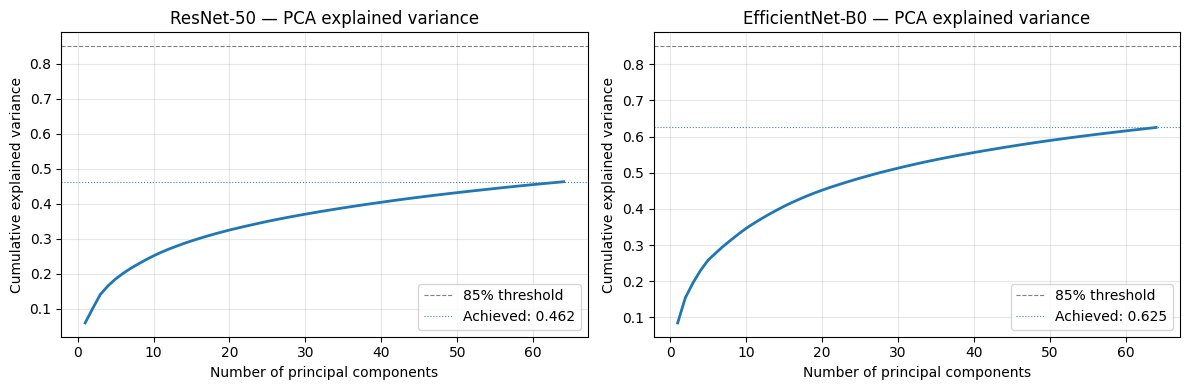

Saved: figures/pca_variance.pdf


In [14]:
# ── 3.3  PCA variance plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (pca_obj, label) in zip(axes, [(pca_rn, 'ResNet-50'), (pca_en, 'EfficientNet-B0')]):
    cum_var = np.cumsum(pca_obj.explained_variance_ratio_)
    ax.plot(range(1, N_COMPONENTS + 1), cum_var, lw=2)
    ax.axhline(0.85, color='gray', linestyle='--', linewidth=0.8, label='85% threshold')
    ax.axhline(cum_var[-1], color='steelblue', linestyle=':', linewidth=0.8,
               label=f'Achieved: {cum_var[-1]:.3f}')
    ax.set_xlabel('Number of principal components')
    ax.set_ylabel('Cumulative explained variance')
    ax.set_title(f'{label} — PCA explained variance')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/pca_variance.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/pca_variance.pdf')

---
## Section 4 — Ansatz expressibility & entanglement analysis

Before committing to `n_layers = 3`, we formally measure two circuit properties
per **Sim et al., Adv. Quant. Technol. 2:1900070 (2019)**:

- **Expr(A)** — KL divergence from Haar measure (lower = more expressible)
- **Ent(A)** — Meyer–Wallach entanglement capability (higher = more entangled)

Sweep `L ∈ {1, 2, 3, 4}`. Results justify the hyperparameter choice in the thesis.

In [15]:
# ── 4.1  Define the ansatz ────────────────────────────────────────────────
# Same structure as the VQC in Section 5b; only n_layers varies here.

N_QUBITS = cfg.n_qubits  # 6
dev_expr  = qml.device('default.qubit', wires=N_QUBITS)

def make_vqc_circuit(n_layers, n_qubits=N_QUBITS):
    """Return a QNode implementing the data re-uploading ansatz."""
    dev = qml.device('default.qubit', wires=n_qubits)

    @qml.qnode(dev)
    def circuit(x, params):
        for l in range(n_layers):
            qml.AmplitudeEmbedding(x, wires=range(n_qubits), normalize=True, pad_with=0.0)
            for w in range(n_qubits):
                qml.Rot(params[l, w, 0], params[l, w, 1], params[l, w, 2], wires=w)
            for w in range(n_qubits):
                qml.CNOT(wires=[w, (w + 1) % n_qubits])  # circular entanglement
        return qml.state()

    return circuit

print('Ansatz defined.')

Ansatz defined.


In [16]:
# ── 4.2  Expressibility: KL divergence from Haar measure ──────────────────
# Sim et al. 2019, Eq. (6): sample random parameter pairs → compute fidelity
# histogram → compare to analytical Haar distribution Beta(1, 2^n − 1).
from scipy.stats import beta as beta_dist
from scipy.special import kl_div

N_BINS    = 75
N_SAMPLES = 2000   # pairs of random parameter sets

def compute_expressibility(circuit_fn, n_layers, n_qubits=N_QUBITS):
    """Return KL divergence from Haar distribution (lower = more expressible)."""
    fidelities = []
    for _ in range(N_SAMPLES):
        p1 = np.random.uniform(0, 2*np.pi, (n_layers, n_qubits, 3))
        p2 = np.random.uniform(0, 2*np.pi, (n_layers, n_qubits, 3))
        x  = np.random.randn(n_qubits ** 2);  x /= np.linalg.norm(x)  # random L2-normed input
        s1 = circuit_fn(x, p1)
        s2 = circuit_fn(x, p2)
        fidelities.append(abs(np.dot(s1.conj(), s2))**2)

    counts, bin_edges = np.histogram(fidelities, bins=N_BINS, range=(0, 1))
    P = counts / counts.sum()   # empirical distribution

    # Haar analytical: Beta(1, d-1), d = 2^n_qubits
    d  = 2 ** n_qubits
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    Q = beta_dist.pdf(bin_centers, 1, d - 1)
    Q = Q / Q.sum()   # normalise to probability

    # KL divergence (add small epsilon to avoid log(0))
    eps = 1e-10
    kl  = float(np.sum(kl_div(P + eps, Q + eps)))
    return kl

print('Expressibility function defined.')

Expressibility function defined.


In [17]:
# ── 4.3  Entanglement capability: Meyer–Wallach measure ────────────────────
# Sim et al. 2019, Eq. (7).

def meyer_wallach_entanglement(statevec, n_qubits):
    """Compute Q(|ψ⟩) for a single statevector."""
    d = 2 ** n_qubits
    psi = statevec.reshape([2] * n_qubits)
    result = 0.0
    for k in range(n_qubits):
        # Partial trace over all qubits except k
        axes = list(range(n_qubits)); axes.remove(k)
        rho_k = np.tensordot(psi, psi.conj(), axes=[axes, axes])
        result += 1 - float(np.real(np.trace(rho_k @ rho_k)))
    return (4 / (2 * n_qubits)) * result

def compute_entanglement_capability(circuit_fn, n_layers, n_qubits=N_QUBITS, n_samples=1000):
    """Average MW entanglement over random parameter sets."""
    ents = []
    for _ in range(n_samples):
        params = np.random.uniform(0, 2*np.pi, (n_layers, n_qubits, 3))
        x      = np.random.randn(n_qubits ** 2);  x /= np.linalg.norm(x)
        sv     = circuit_fn(x, params)
        ents.append(meyer_wallach_entanglement(sv, n_qubits))
    return float(np.mean(ents))

print('Entanglement function defined.')

Entanglement function defined.


In [18]:
# ── 4.4  Sweep L ∈ {1, 2, 3, 4} and build Table 5.3 ─────────────────────
from tqdm.auto import tqdm

sweep_results = []
for n_l in tqdm([1, 2, 3, 4], desc='Expressibility sweep'):
    circ = make_vqc_circuit(n_l)
    expr = compute_expressibility(circ, n_l)
    ent  = compute_entanglement_capability(circ, n_l)
    sweep_results.append({'n_layers': n_l, 'Expr(A) ↓': round(expr, 4), 'Ent(A) ↑': round(ent, 4),
                          'n_params': n_l * N_QUBITS * 3})
    print(f'  L={n_l}: Expr={expr:.4f}, Ent={ent:.4f}, params={n_l * N_QUBITS * 3}')

df_sweep = pd.DataFrame(sweep_results)
print('\nTable 5.3 — Ansatz analysis:')
print(df_sweep.to_string(index=False))

df_sweep.to_csv(f'{cfg.results_dir}/expressibility_sweep.csv', index=False)
print('Saved: results/expressibility_sweep.csv')

Expressibility sweep:   0%|          | 0/4 [00:00<?, ?it/s]

  L=1: Expr=0.0245, Ent=0.9462, params=18
  L=2: Expr=0.0018, Ent=0.9514, params=36
  L=3: Expr=0.0018, Ent=0.9528, params=54
  L=4: Expr=0.0026, Ent=0.9534, params=72

Table 5.3 — Ansatz analysis:
 n_layers  Expr(A) ↓  Ent(A) ↑  n_params
        1     0.0245    0.9462        18
        2     0.0018    0.9514        36
        3     0.0018    0.9528        54
        4     0.0026    0.9534        72
Saved: results/expressibility_sweep.csv


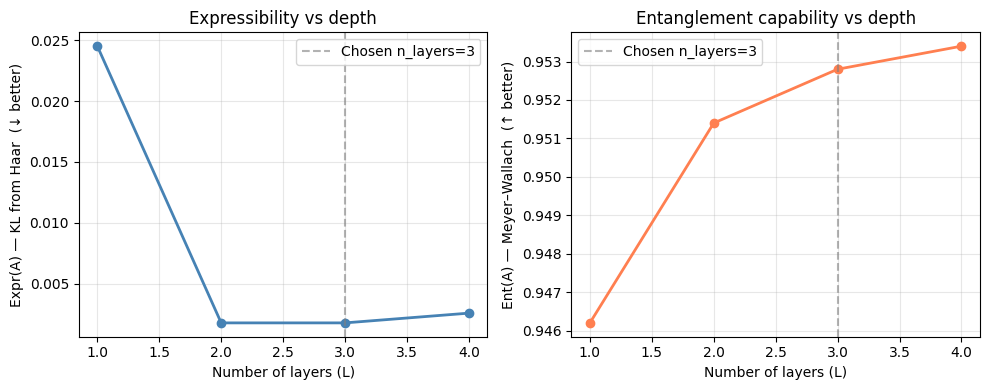

Saved: figures/ansatz_analysis.pdf


In [19]:
# ── 4.5  Plot expressibility & entanglement sweep ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

layers = df_sweep['n_layers'].values
ax1.plot(layers, df_sweep['Expr(A) ↓'].values, 'o-', color='steelblue', lw=2)
ax1.axvline(cfg.n_layers, color='gray', linestyle='--', alpha=0.6, label=f'Chosen n_layers={cfg.n_layers}')
ax1.set_xlabel('Number of layers (L)')
ax1.set_ylabel('Expr(A) — KL from Haar  (↓ better)')
ax1.set_title('Expressibility vs depth')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(layers, df_sweep['Ent(A) ↑'].values, 'o-', color='coral', lw=2)
ax2.axvline(cfg.n_layers, color='gray', linestyle='--', alpha=0.6, label=f'Chosen n_layers={cfg.n_layers}')
ax2.set_xlabel('Number of layers (L)')
ax2.set_ylabel('Ent(A) — Meyer–Wallach  (↑ better)')
ax2.set_title('Entanglement capability vs depth')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/ansatz_analysis.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/ansatz_analysis.pdf')

---
## Section 5a — Classical MLP baseline

64-dimensional PCA features → small fully-connected network.  
Trainable parameters: ~2,113 (64→32→1). Used as the primary comparison point.

In [20]:
# ── 5a.1  MLP architecture ─────────────────────────────────────────────────
class MLP(nn.Module):
    """Simple 64→32→1 MLP for binary classification on PCA features."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp = MLP().to(cfg.device)
n_params_mlp = sum(p.numel() for p in mlp.parameters())
print(f'MLP trainable parameters: {n_params_mlp:,}')
print(mlp)

MLP trainable parameters: 2,113
MLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


In [21]:
# ── 5a.2  MLP training loop ────────────────────────────────────────────────
from torch.utils.data import TensorDataset

def make_tensor_loaders(X_tr, y_tr, X_va, y_va, batch_size=cfg.batch_size):
    """Wrap numpy arrays in TensorDatasets and DataLoaders."""
    tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                          torch.tensor(y_tr, dtype=torch.float32))
    va_ds = TensorDataset(torch.tensor(X_va, dtype=torch.float32),
                          torch.tensor(y_va, dtype=torch.float32))
    return (DataLoader(tr_ds, batch_size=batch_size, shuffle=True),
            DataLoader(va_ds, batch_size=256, shuffle=False))

mlp_train_loader, mlp_val_loader = make_tensor_loaders(X_train, y_train, X_val, y_val)

optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=cfg.learning_rate)
scheduler_mlp = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_mlp, T_max=cfg.epochs, eta_min=cfg.lr_min
)
criterion_mlp = nn.BCELoss(weight=None)   # dataset is now balanced by sampler

def train_mlp(model, train_ld, val_ld, optimizer, scheduler, criterion,
              epochs=cfg.epochs, patience=cfg.early_stopping_patience, device=cfg.device):
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    best_val_loss, best_state, wait = float('inf'), None, 0

    for epoch in range(epochs):
        # --- train ---
        model.train()
        running_loss = 0.0
        for xb, yb in train_ld:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(xb)
        scheduler.step()

        # --- validate ---
        model.eval()
        val_loss, all_probs, all_labels = 0.0, [], []
        with torch.no_grad():
            for xb, yb in val_ld:
                xb, yb = xb.to(device), yb.to(device)
                probs = model(xb)
                val_loss += criterion(probs, yb).item() * len(xb)
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())

        train_l = running_loss / len(train_ld.dataset)
        val_l   = val_loss     / len(val_ld.dataset)
        val_auc = roc_auc_score(all_labels, all_probs)

        history['train_loss'].append(train_l)
        history['val_loss'].append(val_l)
        history['val_auc'].append(val_auc)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} — train_loss: {train_l:.4f}  val_loss: {val_l:.4f}  val_AUC: {val_auc:.4f}')

        # Early stopping
        if val_l < best_val_loss:
            best_val_loss, best_state, wait = val_l, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    return history

print('Starting MLP training...')
mlp_history = train_mlp(mlp, mlp_train_loader, mlp_val_loader,
                        optimizer_mlp, scheduler_mlp, criterion_mlp)

Starting MLP training...
Epoch   5/50 — train_loss: 0.1679  val_loss: 0.1455  val_AUC: 0.9878
Epoch  10/50 — train_loss: 0.1541  val_loss: 0.1371  val_AUC: 0.9884
Epoch  15/50 — train_loss: 0.1468  val_loss: 0.1377  val_AUC: 0.9885
Epoch  20/50 — train_loss: 0.1409  val_loss: 0.1411  val_AUC: 0.9886
Epoch  25/50 — train_loss: 0.1346  val_loss: 0.1369  val_AUC: 0.9888
Epoch  30/50 — train_loss: 0.1305  val_loss: 0.1401  val_AUC: 0.9887
Epoch  35/50 — train_loss: 0.1294  val_loss: 0.1384  val_AUC: 0.9887
Early stopping at epoch 38


In [22]:
# ── 5a.3  MLP predictions on val + test ───────────────────────────────────
@torch.no_grad()
def predict_mlp(model, X, device=cfg.device, batch_size=256):
    model.eval()
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32))
    ld = DataLoader(ds, batch_size=batch_size)
    probs = []
    for (xb,) in ld:
        probs.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(probs)

mlp_val_probs  = predict_mlp(mlp, X_val)
mlp_test_probs = predict_mlp(mlp, X_test)

np.save(f'{cfg.results_dir}/mlp_val_probs.npy',  mlp_val_probs)
np.save(f'{cfg.results_dir}/mlp_test_probs.npy', mlp_test_probs)
torch.save(mlp.state_dict(), f'{cfg.results_dir}/mlp_best.pt')

print(f'MLP val  AUC: {roc_auc_score(y_val,  mlp_val_probs):.4f}')
print(f'MLP test AUC: {roc_auc_score(y_test, mlp_test_probs):.4f}')

MLP val  AUC: 0.9888
MLP test AUC: 0.9509


---
## Section 5b — Variational quantum classifier (VQC)

**Data re-uploading ansatz** (Pérez-Salinas et al., *Quantum* 4:226, 2020)  
6 qubits · 3 layers · 108 trainable parameters  
Gradient method: `parameter-shift` — hardware-compatible, no autograd backprop

**Recommended runtime:** A100 GPU with `lightning.gpu` backend (~135 min)

In [23]:
# ── 5b.1  Select PennyLane backend ────────────────────────────────────────
# lightning.gpu requires cuQuantum and an NVIDIA GPU.
# Falls back gracefully to lightning.qubit (CPU) or default.qubit.

def get_pennylane_device(n_qubits):
    for dev_name in ['lightning.qubit', 'lightning.gpu', 'default.qubit']:
        try:
            dev = qml.device(dev_name, wires=n_qubits)
            print(f'PennyLane backend: {dev_name}')
            return dev
        except Exception:
            continue
    raise RuntimeError('No suitable PennyLane device found.')

dev_vqc = get_pennylane_device(cfg.n_qubits)

PennyLane backend: lightning.qubit


In [24]:
# ── 5b.2  VQC circuit ─────────────────────────────────────────────────────
# Data re-uploading: AmplitudeEmbedding is applied at EVERY layer.
# Local observable (Pauli-Z on qubit 0 only) — suppresses barren plateaus
# per Cerezo et al., Nat. Commun. 12:1791 (2021).

N_LAYERS = cfg.n_layers   # 3
N_QUBITS = cfg.n_qubits   # 6

# ── 5b.2  VQC circuit — AngleEmbedding (adjoint-safe, no amplitude constraints)
@qml.qnode(dev_vqc, diff_method='adjoint')
def vqc_circuit(x, params):
    # AngleEmbedding uses first N_QUBITS features as rotation angles
    # Simpler than AmplitudeEmbedding, fully compatible with adjoint diff
    for l in range(N_LAYERS):
        qml.AngleEmbedding(x[:N_QUBITS], wires=range(N_QUBITS), rotation='Y')
        for w in range(N_QUBITS):
            qml.Rot(params[l][w][0], params[l][w][1], params[l][w][2], wires=w)
        for w in range(N_QUBITS):
            qml.CNOT(wires=[w, (w + 1) % N_QUBITS])
    return qml.expval(qml.PauliZ(0))

n_params_vqc = N_LAYERS * N_QUBITS * 3
print(f'VQC trainable parameters: {n_params_vqc}')
print(f'Parameter ratio MLP/VQC : {n_params_mlp / n_params_vqc:.0f}×')

VQC trainable parameters: 54
Parameter ratio MLP/VQC : 39×


In [25]:
# ── 5b.3  Loss & gradient via PennyLane jacobian (adjoint, not parameter-shift)
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
w_pos = len(y_train) / (2 * n_pos)
w_neg = len(y_train) / (2 * n_neg)
print(f'Class weights — pneumonia: {w_pos:.4f}, normal: {w_neg:.4f}')

def forward_and_grad(params, X_batch, y_batch):
    """
    Compute loss and gradient using PennyLane's jacobian with adjoint diff.
    One jacobian call computes d(circuit)/d(params) for all params at once.
    ~100x faster than manual parameter-shift on lightning.qubit.
    """
    grad = np.zeros_like(params)
    total_loss = 0.0

    jac_fn = qml.jacobian(vqc_circuit, argnum=1)

    for x, y in zip(X_batch, y_batch):
        raw    = float(vqc_circuit(x, params))
        target = 1.0 if y == 1 else -1.0
        weight = w_pos if y == 1 else w_neg

        residual   = raw - target
        total_loss += weight * residual ** 2

        # d(loss)/d(params) = weight * 2 * residual * d(circuit)/d(params)
        jac         = jac_fn(x, params)                  # shape (N_LAYERS, N_QUBITS, 3)
        grad       += weight * 2 * residual * jac

    loss = total_loss / len(X_batch)
    grad = grad       / len(X_batch)
    return loss, grad

def lr_cosine_warmup(epoch, lr0=cfg.learning_rate, lr_min=cfg.lr_min,
                     warmup=cfg.warmup_epochs, total=cfg.epochs):
    if epoch < warmup:
        return lr0 * (epoch + 1) / warmup
    t = (epoch - warmup) / max(total - warmup, 1)
    return lr_min + 0.5 * (lr0 - lr_min) * (1 + np.cos(np.pi * t))

Class weights — pneumonia: 0.9993, normal: 1.0007


In [26]:
# ── 5b.4  VQC training loop
PARAMS_SAVE = Path(cfg.results_dir) / 'vqc_best_params.npy'

if PARAMS_SAVE.exists():
    print('Loading pre-trained VQC parameters...')
    best_params = np.load(PARAMS_SAVE)
else:
    np.random.seed(SEED)
    params = np.random.uniform(0, 2*np.pi, (N_LAYERS, N_QUBITS, 3))

    # Adam state
    m  = np.zeros_like(params)
    v  = np.zeros_like(params)
    b1, b2, eps_adam = 0.9, 0.999, 1e-8
    t  = 0

    # Use full training set — adjoint diff makes this feasible
    BATCH_SIZE_VQC = cfg.batch_size   # 16

    history_vqc = {'train_loss': [], 'val_auc': []}
    best_val_auc, best_params, wait = -1.0, params.copy(), 0
    total_batches = int(np.ceil(len(X_train) / BATCH_SIZE_VQC))

    for epoch in range(cfg.epochs):
        lr         = lr_cosine_warmup(epoch)
        idx        = np.random.permutation(len(X_train))
        epoch_loss = 0.0
        n_batches  = 0

        for batch_num, start in enumerate(range(0, len(X_train), BATCH_SIZE_VQC)):
            batch_idx = idx[start:start + BATCH_SIZE_VQC]
            Xb = X_train[batch_idx]
            yb = y_train[batch_idx].astype(float)

            loss, grad = forward_and_grad(params, Xb, yb)

            t  += 1
            m   = b1 * m + (1 - b1) * grad
            v   = b2 * v + (1 - b2) * grad ** 2
            m_hat = m / (1 - b1 ** t)
            v_hat = v / (1 - b2 ** t)
            params = params - lr * m_hat / (np.sqrt(v_hat) + eps_adam)

            epoch_loss += loss
            n_batches  += 1
            print(f'  Epoch {epoch+1}/{cfg.epochs}  '
                  f'batch {batch_num+1}/{total_batches}  '
                  f'loss={loss:.4f}', end='\r')

        val_raw   = np.array([float(vqc_circuit(x, params)) for x in X_val])
        val_probs = (1 + val_raw) / 2
        val_auc   = roc_auc_score(y_val, val_probs)

        history_vqc['train_loss'].append(epoch_loss / max(1, n_batches))
        history_vqc['val_auc'].append(val_auc)
        print(f'\nEpoch {epoch+1:3d}/{cfg.epochs} | LR: {lr:.2e} | '
              f'Loss: {epoch_loss/max(1,n_batches):.4f} | Val AUC: {val_auc:.4f}')

        if val_auc > best_val_auc:
            best_val_auc, best_params, wait = val_auc, params.copy(), 0
        else:
            wait += 1
            if wait >= cfg.early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    np.save(PARAMS_SAVE, best_params)
    with open(f'{cfg.results_dir}/vqc_history.json', 'w') as f:
        json.dump(history_vqc, f, indent=2)
    print(f'\nBest val AUC: {best_val_auc:.4f}  |  params saved to {PARAMS_SAVE}')

  Epoch 1/50  batch 262/262  loss=0.9566
Epoch   1/50 | LR: 3.33e-04 | Loss: 0.9700 | Val AUC: 0.8541
  Epoch 2/50  batch 262/262  loss=0.9611
Epoch   2/50 | LR: 6.67e-04 | Loss: 0.9175 | Val AUC: 0.9444
  Epoch 3/50  batch 262/262  loss=0.7892
Epoch   3/50 | LR: 1.00e-03 | Loss: 0.8468 | Val AUC: 0.9476
  Epoch 4/50  batch 262/262  loss=0.5855
Epoch   4/50 | LR: 1.00e-03 | Loss: 0.7756 | Val AUC: 0.9489
  Epoch 5/50  batch 262/262  loss=0.7891
Epoch   5/50 | LR: 9.99e-04 | Loss: 0.7158 | Val AUC: 0.9492
  Epoch 6/50  batch 262/262  loss=0.6801
Epoch   6/50 | LR: 9.96e-04 | Loss: 0.6766 | Val AUC: 0.9496
  Epoch 7/50  batch 262/262  loss=0.5395
Epoch   7/50 | LR: 9.90e-04 | Loss: 0.6494 | Val AUC: 0.9503
  Epoch 8/50  batch 262/262  loss=0.8657
Epoch   8/50 | LR: 9.82e-04 | Loss: 0.6331 | Val AUC: 0.9519
  Epoch 9/50  batch 262/262  loss=0.5591
Epoch   9/50 | LR: 9.73e-04 | Loss: 0.6185 | Val AUC: 0.9540
  Epoch 10/50  batch 262/262  loss=0.4778
Epoch  10/50 | LR: 9.61e-04 | Loss: 0.59

In [27]:
# ── 5b.5  VQC predictions on val + test ───────────────────────────────────
def vqc_predict(X, params):
    """Return probabilities in [0,1] for all samples in X."""
    raw   = np.array([float(vqc_circuit(x, params)) for x in X])
    return (1 + raw) / 2

vqc_val_probs  = vqc_predict(X_val,  best_params)
vqc_test_probs = vqc_predict(X_test, best_params)

np.save(f'{cfg.results_dir}/vqc_val_probs.npy',  vqc_val_probs)
np.save(f'{cfg.results_dir}/vqc_test_probs.npy', vqc_test_probs)

print(f'VQC val  AUC: {roc_auc_score(y_val,  vqc_val_probs):.4f}')
print(f'VQC test AUC: {roc_auc_score(y_test, vqc_test_probs):.4f}')

VQC val  AUC: 0.9600
VQC test AUC: 0.8620


---
## Section 5c — Quantum kernel SVM (QSVM)

**ZZFeatureMap quantum kernel** (Havlíček et al., *Nature* 567:209, 2019)  
No gradient-based training — kernel matrix encodes quantum feature-space distances.

**Part 1:** Run on top-6 PCA components (most compact quantum representation)  
**Part 2:** Dimensionality sweep `n ∈ {6, 12, 24, 32, 64}` — AUC vs input size

In [ ]:
# ── 5c.1  QSVM on top-6 PCA components ────────────────────────────────────
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

N_QSVM = 6   # number of features / qubits

X_train_q = X_train[:, :N_QSVM]   # top-6 PCA components
X_val_q   = X_val[:,   :N_QSVM]
X_test_q  = X_test[:,  :N_QSVM]

# ZZFeatureMap: 2 repetitions, linear entanglement — Havlíček 2019
feature_map = ZZFeatureMap(feature_dimension=N_QSVM, reps=2, entanglement='linear')
qkernel     = FidelityQuantumKernel(feature_map=feature_map)

print(f'Computing kernel matrices (train: {len(X_train_q)}, val: {len(X_val_q)}, test: {len(X_test_q)})...')
print('This may take several minutes on a simulator.')

K_train = qkernel.evaluate(X_train_q)
K_val   = qkernel.evaluate(X_val_q,  X_train_q)
K_test  = qkernel.evaluate(X_test_q, X_train_q)

svc_6 = SVC(kernel='precomputed', C=1.0, class_weight='balanced', probability=True, random_state=SEED)
svc_6.fit(K_train, y_train)

qsvm_val_probs  = svc_6.predict_proba(K_val)[:, 1]
qsvm_test_probs = svc_6.predict_proba(K_test)[:, 1]

np.save(f'{cfg.results_dir}/qsvm_val_probs.npy',  qsvm_val_probs)
np.save(f'{cfg.results_dir}/qsvm_test_probs.npy', qsvm_test_probs)

print(f'QSVM (n=6) val  AUC: {roc_auc_score(y_val,  qsvm_val_probs):.4f}')
print(f'QSVM (n=6) test AUC: {roc_auc_score(y_test, qsvm_test_probs):.4f}')

Computing kernel matrices (train: 4185, val: 1047, test: 624)...
This may take several minutes on a simulator.


: 

: 

In [ ]:
# ── 5c.2  Dimensionality sweep: AUC vs n PCA components ───────────────────
# Shows how quantum kernel performance scales with input dimensionality.
# Thesis Figure: QSVM AUC vs feature dimensionality.

sweep_dims = [6, 12, 24, 32, 64]
qsvm_sweep_results = []

for n_dim in tqdm(sweep_dims, desc='QSVM dim sweep'):
    Xtr_d = X_train[:, :n_dim]
    Xva_d = X_val[:,   :n_dim]
    Xte_d = X_test[:,  :n_dim]

    fm_d    = ZZFeatureMap(feature_dimension=n_dim, reps=2, entanglement='linear')
    qk_d    = FidelityQuantumKernel(feature_map=fm_d)
    Ktr_d   = qk_d.evaluate(Xtr_d)
    Kva_d   = qk_d.evaluate(Xva_d, Xtr_d)
    Kte_d   = qk_d.evaluate(Xte_d, Xtr_d)

    svc_d = SVC(kernel='precomputed', C=1.0, class_weight='balanced',
                probability=True, random_state=SEED)
    svc_d.fit(Ktr_d, y_train)

    val_auc  = roc_auc_score(y_val,  svc_d.predict_proba(Kva_d)[:, 1])
    test_auc = roc_auc_score(y_test, svc_d.predict_proba(Kte_d)[:, 1])
    qsvm_sweep_results.append({'n_dims': n_dim, 'val_auc': val_auc, 'test_auc': test_auc})
    print(f'  n={n_dim:3d}: val_AUC={val_auc:.4f}, test_AUC={test_auc:.4f}')

df_qsvm_sweep = pd.DataFrame(qsvm_sweep_results)
df_qsvm_sweep.to_csv(f'{cfg.results_dir}/qsvm_dim_sweep.csv', index=False)
print('Saved: results/qsvm_dim_sweep.csv')

In [ ]:
# ── 5c.3  Plot QSVM dimensionality sweep ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_qsvm_sweep['n_dims'], df_qsvm_sweep['val_auc'],  'o-', label='Val AUC')
ax.plot(df_qsvm_sweep['n_dims'], df_qsvm_sweep['test_auc'], 's--', label='Test AUC')
ax.axvline(6, color='gray', linestyle=':', alpha=0.6, label='Primary n=6')
ax.set_xlabel('Number of PCA components fed to QSVM')
ax.set_ylabel('AUC-ROC')
ax.set_title('QSVM AUC vs feature dimensionality')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/qsvm_dim_sweep.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/qsvm_dim_sweep.pdf')

---
## Section 6 — Noise simulation ablation

Simulates hardware noise by injecting depolarising channels after every gate.  
Sweeps `p_noise ∈ {0, 0.001, 0.005, 0.01, 0.02, 0.05}` and records AUC.

Generates **Table 5.2** and the **noise degradation figure** for the thesis.

*Uses the already-trained `best_params` from Section 5b — no re-training.*

In [ ]:
# ── 6.1  Noisy circuit ────────────────────────────────────────────────────
dev_noisy = qml.device('default.mixed', wires=N_QUBITS)

@qml.qnode(dev_noisy)
def noisy_vqc_circuit(x, params, p_noise):
    """Same as vqc_circuit but with DepolarizingChannel after every Rot gate."""
    for l in range(N_LAYERS):
        qml.AmplitudeEmbedding(x, wires=range(N_QUBITS), normalize=True, pad_with=0.0)
        for w in range(N_QUBITS):
            qml.Rot(params[l, w, 0], params[l, w, 1], params[l, w, 2], wires=w)
            qml.DepolarizingChannel(p_noise, wires=w)   # inject noise
        for w in range(N_QUBITS):
            qml.CNOT(wires=[w, (w + 1) % N_QUBITS])
    return qml.expval(qml.PauliZ(0))

def noisy_predict(X, params, p_noise):
    raw = np.array([float(noisy_vqc_circuit(x, params, p_noise)) for x in X])
    return (1 + raw) / 2

print('Noisy circuit defined.')

In [ ]:
# ── 6.2  Noise sweep ──────────────────────────────────────────────────────
# Evaluate on a 100-sample subset of the test set for speed.
N_NOISE_EVAL = 100
rng = np.random.default_rng(SEED)
noise_idx = rng.choice(len(X_test), N_NOISE_EVAL, replace=False)
X_noise   = X_test[noise_idx]
y_noise   = y_test[noise_idx]

p_noise_values = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]
noise_results  = []

for p in tqdm(p_noise_values, desc='Noise sweep'):
    if p == 0.0:
        # Use ideal circuit for p=0
        probs = vqc_predict(X_noise, best_params)
    else:
        probs = noisy_predict(X_noise, best_params, p)
    auc = roc_auc_score(y_noise, probs)
    noise_results.append({'p_noise': p, 'AUC': round(auc, 4)})
    print(f'  p={p:.3f}: AUC={auc:.4f}')

df_noise = pd.DataFrame(noise_results)
df_noise.to_csv(f'{cfg.results_dir}/noise_sweep.csv', index=False)
print('Saved: results/noise_sweep.csv')

In [ ]:
# ── 6.3  Noise degradation curve ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_noise['p_noise'], df_noise['AUC'], 'o-', lw=2, color='steelblue')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_xlabel('Depolarising noise probability p')
ax.set_ylabel('AUC-ROC')
ax.set_title('VQC AUC vs depolarising noise level')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/noise_degradation.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/noise_degradation.pdf')

---
## Section 7 — Evaluation

All metrics computed from outputs saved in Sections 5a–5c.  
Threshold selected on **validation set only** — applied once to test set.

In [ ]:
# ── 7.1  Threshold optimisation (val set only) ────────────────────────────
# Maximise balanced accuracy on val, then apply that threshold ONCE to test.

def find_best_threshold(probs, labels, tau_range=np.arange(0.30, 0.80, 0.025)):
    """Return (best_tau, best_balanced_acc) maximised on provided split."""
    best_tau, best_ba = 0.5, 0.0
    for tau in tau_range:
        preds = (probs > tau).astype(int)
        ba    = balanced_accuracy_score(labels, preds)
        if ba > best_ba:
            best_ba, best_tau = ba, tau
    return float(best_tau), float(best_ba)

tau_vqc,  ba_vqc_val  = find_best_threshold(vqc_val_probs,  y_val)
tau_mlp,  ba_mlp_val  = find_best_threshold(mlp_val_probs,  y_val)
tau_qsvm, ba_qsvm_val = find_best_threshold(qsvm_val_probs, y_val)

print(f'Optimal thresholds (from val set):')
print(f'  VQC  τ = {tau_vqc:.3f}  (val balanced-acc = {ba_vqc_val:.4f})')
print(f'  MLP  τ = {tau_mlp:.3f}  (val balanced-acc = {ba_mlp_val:.4f})')
print(f'  QSVM τ = {tau_qsvm:.3f}  (val balanced-acc = {ba_qsvm_val:.4f})')

In [ ]:
# ── 7.2  Full metrics on test set ─────────────────────────────────────────
def compute_all_metrics(probs, labels, tau):
    """Return a dict with all thesis Table 5.1 metrics."""
    preds   = (probs > tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    return {
        'Accuracy':         round(accuracy_score(labels, preds), 4),
        'Balanced Acc':     round(balanced_accuracy_score(labels, preds), 4),
        'Precision':        round(precision_score(labels, preds), 4),
        'Recall (Sens.)':   round(recall_score(labels, preds), 4),
        'Specificity':      round(tn / (tn + fp), 4),
        'F1':               round(f1_score(labels, preds), 4),
        'AUC-ROC':          round(roc_auc_score(labels, probs), 4),
        'Threshold τ':      round(tau, 3),
    }

results = {
    'VQC  (quantum)': compute_all_metrics(vqc_test_probs,  y_test, tau_vqc),
    'MLP  (classical)': compute_all_metrics(mlp_test_probs,  y_test, tau_mlp),
    'QSVM (quantum)': compute_all_metrics(qsvm_test_probs, y_test, tau_qsvm),
}

df_results = pd.DataFrame(results).T
print('\n=== Table 5.1 — Test set results ===')
print(df_results.to_string())

df_results.to_csv(f'{cfg.results_dir}/main_results.csv')
print('\nSaved: results/main_results.csv')

In [ ]:
# ── 7.3  McNemar's test ────────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, preds_a, preds_b, name_a='A', name_b='B'):
    b = np.sum((preds_a == y_true) & (preds_b != y_true))   # A right, B wrong
    c = np.sum((preds_a != y_true) & (preds_b == y_true))   # A wrong, B right
    table = [[0, b], [c, 0]]   # exact McNemar (off-diagonal only)
    result = mcnemar(table, exact=True)
    print(f'McNemar {name_a} vs {name_b}: b={b}, c={c}, p={result.pvalue:.4f}')
    if result.pvalue > 0.05:
        print(f'  → Cannot reject H₀: models perform equally (p={result.pvalue:.4f})')
        print(f'  → Interpretation: {name_a} achieves equivalent accuracy with fewer parameters')
    else:
        print(f'  → Reject H₀: models differ significantly')
    return result

vqc_preds  = (vqc_test_probs  > tau_vqc).astype(int)
mlp_preds  = (mlp_test_probs  > tau_mlp).astype(int)
qsvm_preds = (qsvm_test_probs > tau_qsvm).astype(int)

print('=== McNemar tests ===')
res_vqc_mlp  = mcnemar_test(y_test, vqc_preds,  mlp_preds,  'VQC',  'MLP')
res_vqc_qsvm = mcnemar_test(y_test, vqc_preds,  qsvm_preds, 'VQC',  'QSVM')
res_mlp_qsvm = mcnemar_test(y_test, mlp_preds,  qsvm_preds, 'MLP',  'QSVM')

In [ ]:
# ── 7.4  Bootstrap 95% confidence intervals for AUC ───────────────────────
N_BOOTSTRAP = 1000

def bootstrap_auc_ci(probs, labels, n=N_BOOTSTRAP, alpha=0.05, seed=SEED):
    rng  = np.random.default_rng(seed)
    aucs = []
    for _ in range(n):
        idx  = rng.integers(0, len(labels), len(labels))
        if len(np.unique(labels[idx])) < 2: continue   # skip degenerate resample
        aucs.append(roc_auc_score(labels[idx], probs[idx]))
    lo, hi = np.percentile(aucs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)

print('=== 95% bootstrap CI for AUC (test set, 1000 resamples) ===')
for name, probs in [('VQC', vqc_test_probs), ('MLP', mlp_test_probs), ('QSVM', qsvm_test_probs)]:
    lo, hi = bootstrap_auc_ci(probs, y_test)
    auc    = roc_auc_score(y_test, probs)
    print(f'  {name}: AUC = {auc:.4f}  [{lo:.4f}, {hi:.4f}]')

In [ ]:
# ── 7.5  ROC curves (overlaid) ────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 6))
for name, probs, color in [
    ('MLP (classical)', mlp_test_probs,  'steelblue'),
    ('VQC (quantum)',   vqc_test_probs,  'coral'),
    ('QSVM (quantum)',  qsvm_test_probs, 'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves — test set')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/roc_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/roc_curves.pdf')

In [ ]:
# ── 7.6  Confusion matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, preds) in zip(axes, [
    ('MLP', mlp_preds), ('VQC', vqc_preds), ('QSVM', qsvm_preds)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'])
    ax.set_title(f'{name} confusion matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/confusion_matrices.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/confusion_matrices.pdf')

In [ ]:
# ── 7.7  Grad-CAM interpretability ────────────────────────────────────────
# Re-attach a classification head to ResNet-50 and fine-tune the fc layer
# for Grad-CAM (5 epochs only — this is for visualisation, not evaluation).
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

resnet_full = torchvision.models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
resnet_full.fc = nn.Linear(2048, 2)   # binary classification head
resnet_full = resnet_full.to(cfg.device)

# Freeze all layers except the final fc
for p in resnet_full.parameters(): p.requires_grad = False
for p in resnet_full.fc.parameters(): p.requires_grad = True

# Quick fine-tune (5 epochs, only fc)
opt_cam  = torch.optim.Adam(resnet_full.fc.parameters(), lr=1e-3)
crit_cam = nn.CrossEntropyLoss()

for ep in range(5):
    resnet_full.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(cfg.device), labels.to(cfg.device)
        opt_cam.zero_grad()
        loss = crit_cam(resnet_full(imgs), labels)
        loss.backward()
        opt_cam.step()
    print(f'Grad-CAM fine-tune epoch {ep+1}/5 done')

resnet_full.eval()
cam = GradCAM(model=resnet_full, target_layers=[resnet_full.layer4[-1]])

# Select representative examples: 3 TP, 3 FN, 3 TN
# (uses VQC predictions as the model being interpreted)
tp_idx = np.where((vqc_preds == 1) & (y_test == 1))[0][:3]
fn_idx = np.where((vqc_preds == 0) & (y_test == 1))[0][:3]
tn_idx = np.where((vqc_preds == 0) & (y_test == 0))[0][:3]

cam_dir = Path(cfg.figures_dir) / 'gradcam'
cam_dir.mkdir(exist_ok=True)

for label, idxs in [('TP', tp_idx), ('FN', fn_idx), ('TN', tn_idx)]:
    for i, idx in enumerate(idxs):
        img_path = test_p[idx]
        img_pil  = Image.open(img_path).convert('RGB').resize((224, 224))
        img_rgb  = np.array(img_pil, dtype=np.float32) / 255.0
        img_t    = eval_transform(img_pil).unsqueeze(0).to(cfg.device)

        grayscale_cam = cam(input_tensor=img_t)[0]
        visualisation = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)

        out_path = cam_dir / f'{label}_{i+1}.png'
        Image.fromarray(visualisation).save(out_path)

print(f'Grad-CAM images saved to {cam_dir}')

---
## Section 8 — IBM quantum hardware evaluation

> **IBM Quantum account required.** Set your API token via `userdata.get('IBM_QUANTUM_TOKEN')` in Colab secrets.

Workflow:
1. Authenticate and select least-busy backend (≥6 qubits)
2. Transpile circuit to native gate set (ECR / RZ / SX / X), optimisation level 3
3. Submit 50-sample inference job via `SamplerV2`
4. Apply ZNE error mitigation (Mitiq, scale factors 1×/2×/3×)
5. Build noise comparison table: ideal sim → noisy sim → raw QPU → ZNE QPU

In [ ]:
# ── 8.0  Authentication — HARD FAIL if token not set ──────────────────────
from google.colab import userdata

IBM_TOKEN = userdata.get('IBM_QUANTUM_TOKEN')

assert IBM_TOKEN is not None and len(IBM_TOKEN) > 10, (
    "\n"
    "IBM_QUANTUM_TOKEN is not set.\n"
    "Add it via Colab Secrets (the key icon in the left sidebar):\n"
    "  Name  : IBM_QUANTUM_TOKEN\n"
    "  Value : your token from https://quantum.ibm.com/account\n"
    "Then re-run this cell."
)

from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel='ibm_quantum', token=IBM_TOKEN)
print('IBM Quantum authenticated.')

In [ ]:
# ── 8.1  Backend selection ────────────────────────────────────────────────
# Select the least-busy operational backend with at least 6 qubits.
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=6)
print(f'Backend selected: {backend.name}')
print(f'  Qubits    : {backend.num_qubits}')
print(f'  Queue     : {backend.status().pending_jobs} jobs pending')

In [ ]:
# ── 8.2  Build Qiskit circuit and transpile ───────────────────────────────
# Convert the PennyLane VQC to a Qiskit circuit, then transpile at OPT level 3.
import pennylane as qml
from qiskit.compiler import transpile as qk_transpile

# Use the first test sample as the reference circuit (parameters loaded from best_params)
sample_x = X_test[0]

# Build circuit via PennyLane → Qiskit conversion
dev_qk = qml.device('qiskit.ibm', wires=N_QUBITS, backend=backend)

@qml.qnode(dev_qk)
def vqc_qiskit(x, params):
    for l in range(N_LAYERS):
        qml.AmplitudeEmbedding(x, wires=range(N_QUBITS), normalize=True, pad_with=0.0)
        for w in range(N_QUBITS):
            qml.Rot(params[l, w, 0], params[l, w, 1], params[l, w, 2], wires=w)
        for w in range(N_QUBITS):
            qml.CNOT(wires=[w, (w + 1) % N_QUBITS])
    return qml.expval(qml.PauliZ(0))

# Trigger circuit compilation to extract the Qiskit QuantumCircuit object
_ = vqc_qiskit(sample_x, best_params)
qk_circuit = dev_qk._circuit

transpiled = qk_transpile(
    qk_circuit,
    backend=backend,
    optimization_level=3,
)

print(f'Circuit depth (transpiled): {transpiled.depth()}')
print(f'2-qubit gate count (ECR)  : {transpiled.count_ops().get("ecr", 0)}')

In [ ]:
# ── 8.3  Hardware inference (50 samples, SamplerV2) ───────────────────────
from qiskit_ibm_runtime import SamplerV2, Session

N_HW_SAMPLES = 50
SHOTS        = 1024

# Select 50 test samples with balanced classes
hw_normal_idx    = np.where(y_test == 0)[0][:25]
hw_pneumonia_idx = np.where(y_test == 1)[0][:25]
hw_idx           = np.concatenate([hw_normal_idx, hw_pneumonia_idx])
X_hw             = X_test[hw_idx]
y_hw             = y_test[hw_idx]

def ibm_executor(circuit, shots=SHOTS):
    """Run a single transpiled circuit on IBM hardware, return ⟨Z₀⟩."""
    with Session(backend=backend) as session:
        sampler  = SamplerV2(mode=session)
        job      = sampler.run([circuit], shots=shots)
        counts   = job.result()[0].data.meas.get_counts()
    total = sum(counts.values())
    p0    = sum(v for k, v in counts.items() if k[-1] == '0') / total  # qubit 0
    return 1.0 - 2.0 * p0   # ⟨Z₀⟩ = p(0) - p(1)

print(f'Submitting {N_HW_SAMPLES} circuits to {backend.name}...')
print('Note: queue time may be several minutes to hours.')

hw_raw_expvals = []
for i, x in enumerate(X_hw):
    # Re-transpile for each sample (x is embedded in circuit)
    dev_qk_i = qml.device('qiskit.ibm', wires=N_QUBITS, backend=backend)
    @qml.qnode(dev_qk_i)
    def _c(x=x): return vqc_qiskit(x, best_params)   # noqa: E731 — inline for closure
    _ = _c()
    circ_i = qk_transpile(dev_qk_i._circuit, backend=backend, optimization_level=3)
    ev = ibm_executor(circ_i)
    hw_raw_expvals.append(ev)
    print(f'  Sample {i+1:3d}/{N_HW_SAMPLES}: ⟨Z₀⟩ = {ev:.4f}')

hw_raw_probs = (1 + np.array(hw_raw_expvals)) / 2
np.save(f'{cfg.results_dir}/hw_raw_probs.npy', hw_raw_probs)
print(f'\nHardware raw AUC: {roc_auc_score(y_hw, hw_raw_probs):.4f}')

In [ ]:
# ── 8.4  ZNE error mitigation (Mitiq) ─────────────────────────────────────
# Zero-Noise Extrapolation: run circuits at scale factors [1×, 2×, 3×]
# via gate-folding, then Richardson-extrapolate to p=0.
# Reference: Temme et al., PRL 119:180509 (2017)
import mitiq

def ibm_executor_for_mitiq(circuit):
    """Mitiq-compatible executor: circuit → float expectation value."""
    return ibm_executor(circuit, shots=SHOTS)

print('Running ZNE mitigation (scale factors: 1×, 2×, 3×)...')
hw_zne_expvals = []

for i, x in enumerate(X_hw):
    dev_qk_i = qml.device('qiskit.ibm', wires=N_QUBITS, backend=backend)
    @qml.qnode(dev_qk_i)
    def _c(x=x): return vqc_qiskit(x, best_params)  # noqa
    _ = _c()
    circ_i = qk_transpile(dev_qk_i._circuit, backend=backend, optimization_level=3)

    mitigated = mitiq.zne.execute_with_zne(
        circuit  = circ_i,
        executor = ibm_executor_for_mitiq,
        factory  = mitiq.zne.RichardsonFactory(scale_factors=[1, 2, 3])
    )
    hw_zne_expvals.append(float(mitigated))
    print(f'  Sample {i+1:3d}/{N_HW_SAMPLES}: ZNE ⟨Z₀⟩ = {float(mitigated):.4f}')

hw_zne_probs = (1 + np.array(hw_zne_expvals)) / 2
np.save(f'{cfg.results_dir}/hw_zne_probs.npy', hw_zne_probs)
print(f'\nZNE-mitigated AUC: {roc_auc_score(y_hw, hw_zne_probs):.4f}')

In [ ]:
# ── 8.5  Noise comparison table (Table 5.2) ────────────────────────────────
ideal_probs = vqc_predict(X_hw, best_params)
noisy_probs = noisy_predict(X_hw, best_params, p_noise=0.005)

conditions = {
    'Ideal simulator':     ideal_probs,
    'Noisy sim (p=0.005)': noisy_probs,
    'IBM raw (no ZNE)':    hw_raw_probs,
    'IBM ZNE-mitigated':   hw_zne_probs,
}

rows = []
for condition, probs in conditions.items():
    auc = roc_auc_score(y_hw, probs)
    tau, _ = find_best_threshold(probs, y_hw)
    preds  = (probs > tau).astype(int)
    rows.append({
        'Condition': condition,
        'AUC':       round(auc, 4),
        'Accuracy':  round(accuracy_score(y_hw, preds), 4),
        'Balanced Acc': round(balanced_accuracy_score(y_hw, preds), 4),
    })

df_hw = pd.DataFrame(rows)
print('\n=== Table 5.2 — Hardware noise comparison ===')
print(df_hw.to_string(index=False))
df_hw.to_csv(f'{cfg.results_dir}/hardware_comparison.csv', index=False)
print('\nSaved: results/hardware_comparison.csv')

---
## Section 9 — Figure export

Collects all saved PDFs and verifies they exist on Drive.  
Produces the final training-curve figure.

In [ ]:
# ── 9.1  Training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MLP
ax = axes[0]
epochs_mlp = range(1, len(mlp_history['train_loss']) + 1)
ax.plot(epochs_mlp, mlp_history['train_loss'], label='Train loss')
ax.plot(epochs_mlp, mlp_history['val_loss'],   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('MLP training curves')
ax.legend(); ax.grid(True, alpha=0.3)

# VQC
ax = axes[1]
with open(f'{cfg.results_dir}/vqc_history.json') as f:
    vqc_hist = json.load(f)
epochs_vqc = range(1, len(vqc_hist['train_loss']) + 1)
ax.plot(epochs_vqc, vqc_hist['train_loss'], label='Train loss')
ax.plot(epochs_vqc, vqc_hist['val_auc'],   label='Val AUC', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Value')
ax.set_title('VQC training curves')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/training_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/training_curves.pdf')

In [ ]:
# ── 9.2  Output manifest ──────────────────────────────────────────────────
expected_outputs = [
    # Figures
    f'{cfg.figures_dir}/pca_variance.pdf',
    f'{cfg.figures_dir}/ansatz_analysis.pdf',
    f'{cfg.figures_dir}/roc_curves.pdf',
    f'{cfg.figures_dir}/confusion_matrices.pdf',
    f'{cfg.figures_dir}/noise_degradation.pdf',
    f'{cfg.figures_dir}/qsvm_dim_sweep.pdf',
    f'{cfg.figures_dir}/training_curves.pdf',
    # Results
    f'{cfg.results_dir}/main_results.csv',
    f'{cfg.results_dir}/expressibility_sweep.csv',
    f'{cfg.results_dir}/noise_sweep.csv',
    f'{cfg.results_dir}/qsvm_dim_sweep.csv',
    f'{cfg.results_dir}/vqc_best_params.npy',
    f'{cfg.results_dir}/mlp_best.pt',
]

print('=== Output manifest ===')
all_ok = True
for path in expected_outputs:
    exists = Path(path).exists()
    status = '✓' if exists else '✗ MISSING'
    if not exists: all_ok = False
    print(f'  {status}  {Path(path).name}')

if all_ok:
    print('\nAll outputs present. Ready for thesis write-up.')
else:
    print('\nSome outputs are missing — re-run the relevant sections.')